# Titanic — Exploratory Data Analysis

**Question:** What factors most strongly predicted survival on the Titanic?

Structure: load data → audit missing values → univariate → bivariate → multivariate → insights.

---

## 1. Setup

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

FIGURES_DIR = 'figures/'
DATA_PATH   = os.path.join('data', 'raw', 'train.csv')

print('Libraries loaded.')

Libraries loaded.


## 2. Load data

In [13]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [15]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Missing value audit

Before anything else: what is missing and is it random or systematic?

In [16]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'count': missing, 'pct_%': missing_pct}).query('count > 0')

,count,pct_%
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2


*Age is missing for ~20% of passengers. Cabin is missing for 77% — too many to reliably impute, so we'll treat it as 'known vs unknown'. Embarked has only 2 missing values.*

## 4. Survival baseline

In [17]:
rate = df['Survived'].mean()
print(f'Overall survival rate: {rate:.1%}')
print(df['Survived'].value_counts())

Overall survival rate: 38.4%
Survived
0    549
1    342
Name: count, dtype: int64


## 5. Bivariate analysis — who survived?

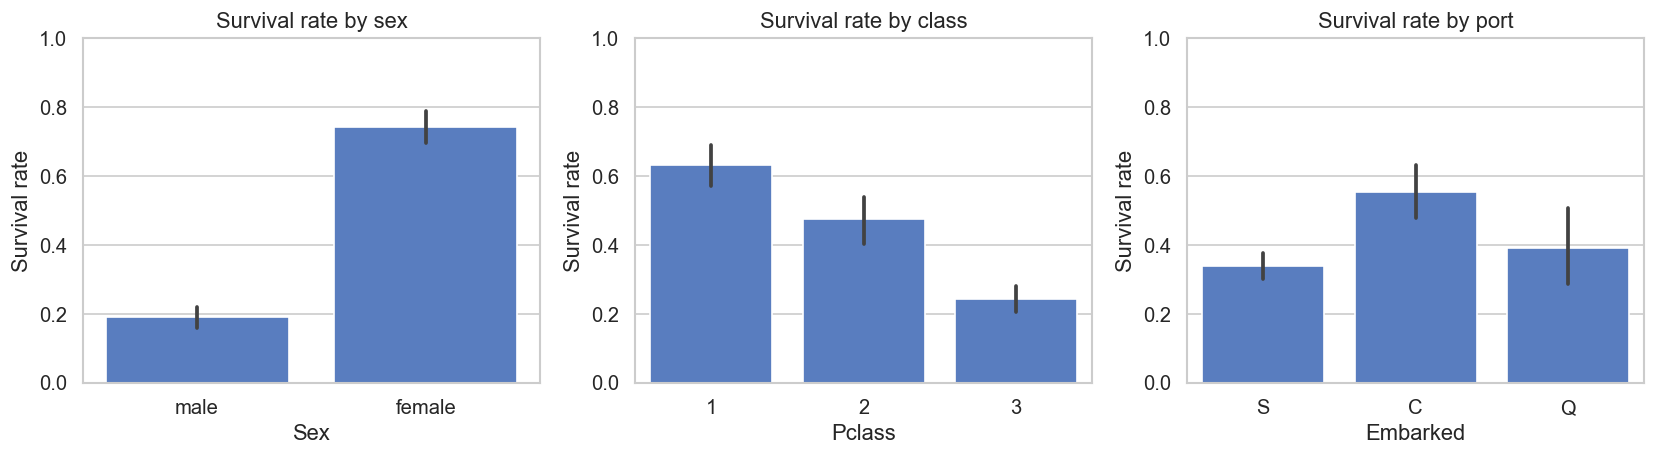

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.barplot(data=df, x='Sex',      y='Survived', ax=axes[0])
sns.barplot(data=df, x='Pclass',   y='Survived', ax=axes[1])
sns.barplot(data=df, x='Embarked', y='Survived', ax=axes[2])

axes[0].set_title('Survival rate by sex')
axes[1].set_title('Survival rate by class')
axes[2].set_title('Survival rate by port')
for ax in axes:
    ax.set_ylabel('Survival rate')
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}survival_by_group.png')
plt.show()

**What we see:**

Sex was the strongest survival predictor — female passengers survived at ~74% vs ~19%
for males. This almost certainly reflects the "women and children first" evacuation
policy enforced by the crew.

Passenger class shows a clear wealth effect — 1st class survived at ~63%, 2nd at ~47%,
and 3rd class at just ~24%. Higher-class passengers had cabins closer to the top deck
and likely better access to lifeboats.

Port of embarkation is interesting but tricky to interpret — Cherbourg (C) passengers
survived at ~57% vs ~38% for Southampton (S). However this is probably not about the
port itself. Cherbourg passengers were more likely to be 1st class — the port effect
likely disappears once you control for class.

## 6. Age distribution

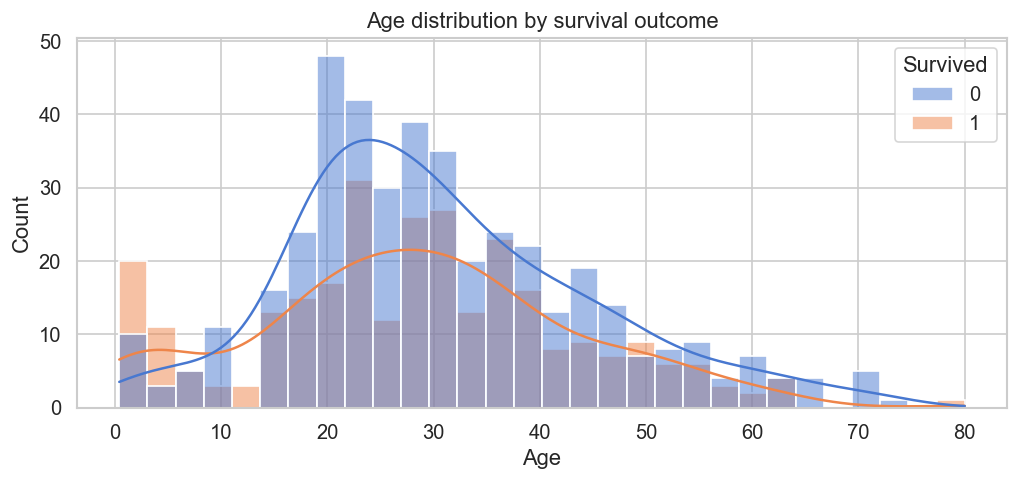

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, ax=ax)
ax.set_title('Age distribution by survival outcome')
plt.savefig(f'{FIGURES_DIR}age_distribution.png')
plt.show()

**What we see:** *Children under ~10 show a notably higher survival proportion — the survived bar is large relative to the died bar in that age range, consistent with "children first"
priority. Young adults (20–35) make up the largest passenger group, so they appear
dominant in both bars, but their survival *rate* is not exceptional. Elderly passengers
(60+) show poor survival — few green bars on the right side of the chart.*

---

## 7. Fare vs survival

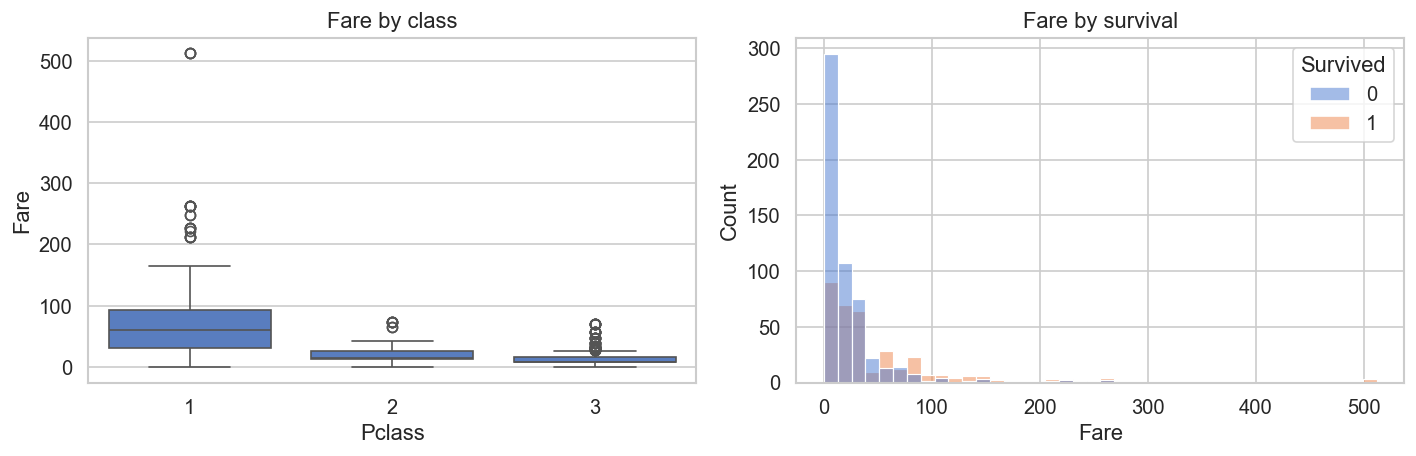

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='Pclass', y='Fare', ax=axes[0])
sns.histplot(data=df, x='Fare', hue='Survived', bins=40, ax=axes[1])

axes[0].set_title('Fare by class')
axes[1].set_title('Fare by survival')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}fare_analysis.png')
plt.show()

## 8. Multivariate — class x sex interaction

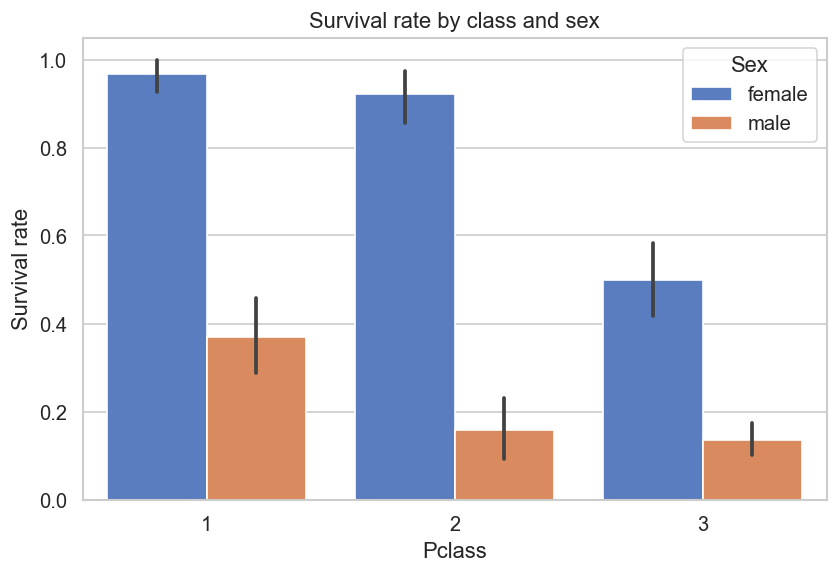

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', ax=ax)
ax.set_title('Survival rate by class and sex')
ax.set_ylabel('Survival rate')
plt.savefig(f'{FIGURES_DIR}survival_class_sex.png')
plt.show()

## 9. Correlation heatmap

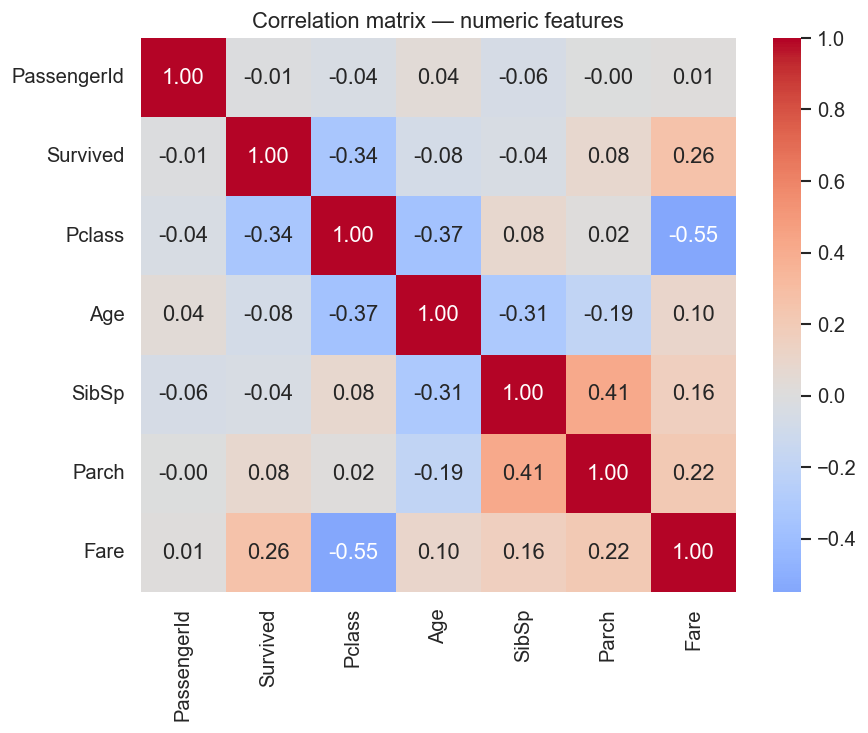

In [22]:
numeric = df.select_dtypes(include=np.number)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix — numeric features')
plt.savefig(f'{FIGURES_DIR}correlation_heatmap.png')
plt.show()

## 10. Key insights summary

1. **Sex was the dominant survival factor.** Female passengers survived at ~74% vs ~19%
   for males — a gap of over 50 percentage points. This single feature will likely be
   the most important predictor in any model we build in Phase 2.

2. **Survival was strongly tied to wealth (passenger class).** 1st class passengers
   survived at 2.5× the rate of 3rd class passengers. This likely reflects both physical
   proximity to lifeboats and social prioritization during evacuation.

3. **Age mattered most at the extremes.** Children under 10 had disproportionately high
   survival rates, while elderly passengers (60+) had very poor outcomes. The large
   20–35 group looks dominant in charts simply because it was the most common age range
   on board.

**What I would do next (Phase 2):** Extract passenger title (Mr, Mrs, Miss, Master)
from the Name column — this encodes both sex and social status in one feature. Impute
missing Age values using the median age per title group rather than the overall median.
Then train a logistic regression and random forest classifier to quantify which features
matter most.